In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries working ✔")

Libraries working ✔


In [5]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(nav.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [10]:
import plotly.express as px

fig = px.line(nav, x="date", y="nav", title="NAV Trend Analysis")
fig.show()

In [11]:
fig = px.line(txn, x="transaction_date", y="amount_inr", title="SIP Trend")
fig.show()

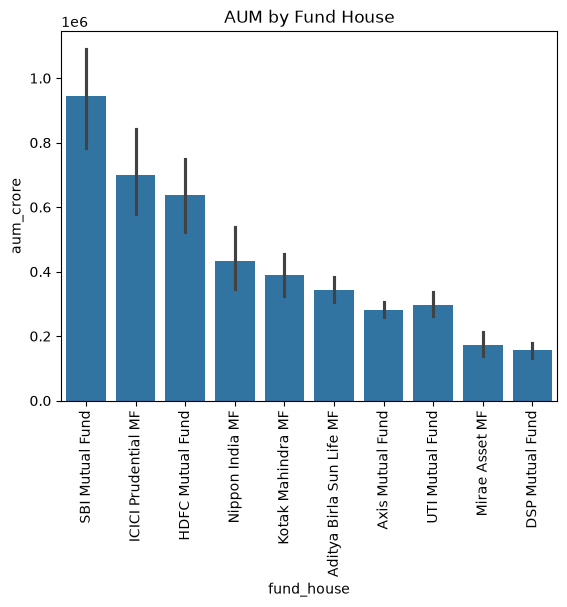

In [12]:
sns.barplot(data=aum, x="fund_house", y="aum_crore")
plt.xticks(rotation=90)
plt.title("AUM by Fund House")
plt.show()

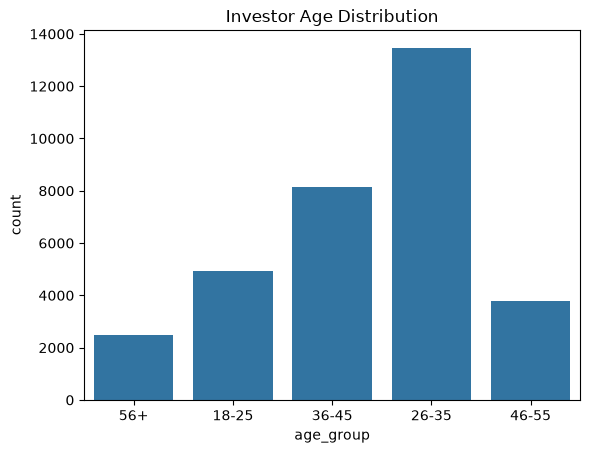

In [13]:
sns.countplot(data=txn, x="age_group")
plt.title("Investor Age Distribution")
plt.show()

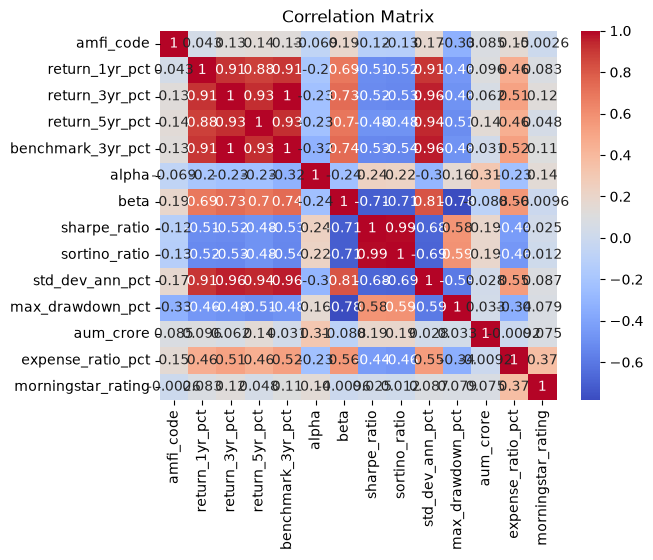

In [14]:
corr = perf.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

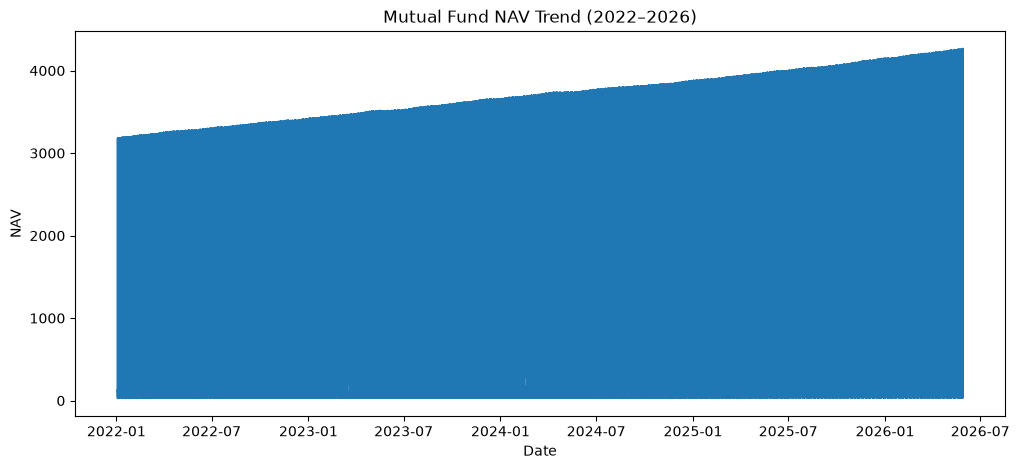

In [15]:
import matplotlib.pyplot as plt

# ensure date is datetime
nav['date'] = pd.to_datetime(nav['date'])

# sort properly
nav = nav.sort_values('date')

plt.figure(figsize=(12,5))
plt.plot(nav['date'], nav['nav'], linewidth=1)

plt.title("Mutual Fund NAV Trend (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

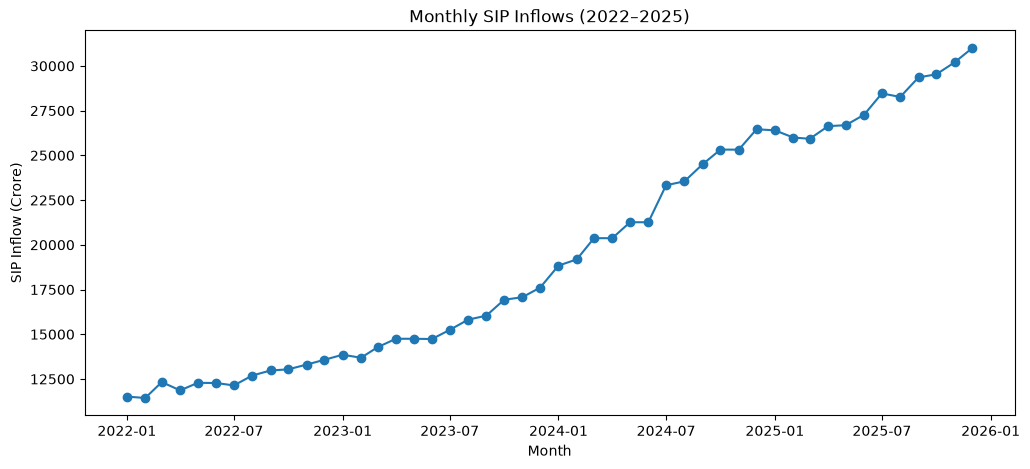

In [16]:
import matplotlib.pyplot as plt

sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

sip['month'] = pd.to_datetime(sip['month'])
sip = sip.sort_values('month')

plt.figure(figsize=(12,5))
plt.plot(sip['month'], sip['sip_inflow_crore'], marker='o')

plt.title("Monthly SIP Inflows (2022–2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.show()

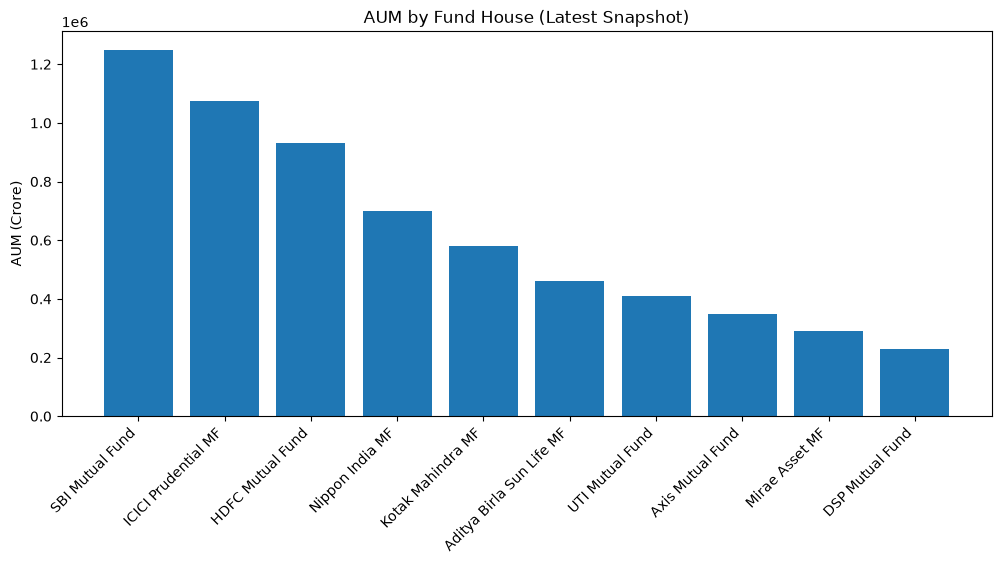

In [17]:
import matplotlib.pyplot as plt

aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

# take latest AUM snapshot (if multiple dates exist)
latest_date = aum['date'].max()
aum_latest = aum[aum['date'] == latest_date]

aum_latest = aum_latest.sort_values('aum_crore', ascending=False)

plt.figure(figsize=(12,5))
plt.bar(aum_latest['fund_house'], aum_latest['aum_crore'])

plt.xticks(rotation=45, ha='right')
plt.title("AUM by Fund House (Latest Snapshot)")
plt.ylabel("AUM (Crore)")
plt.show()

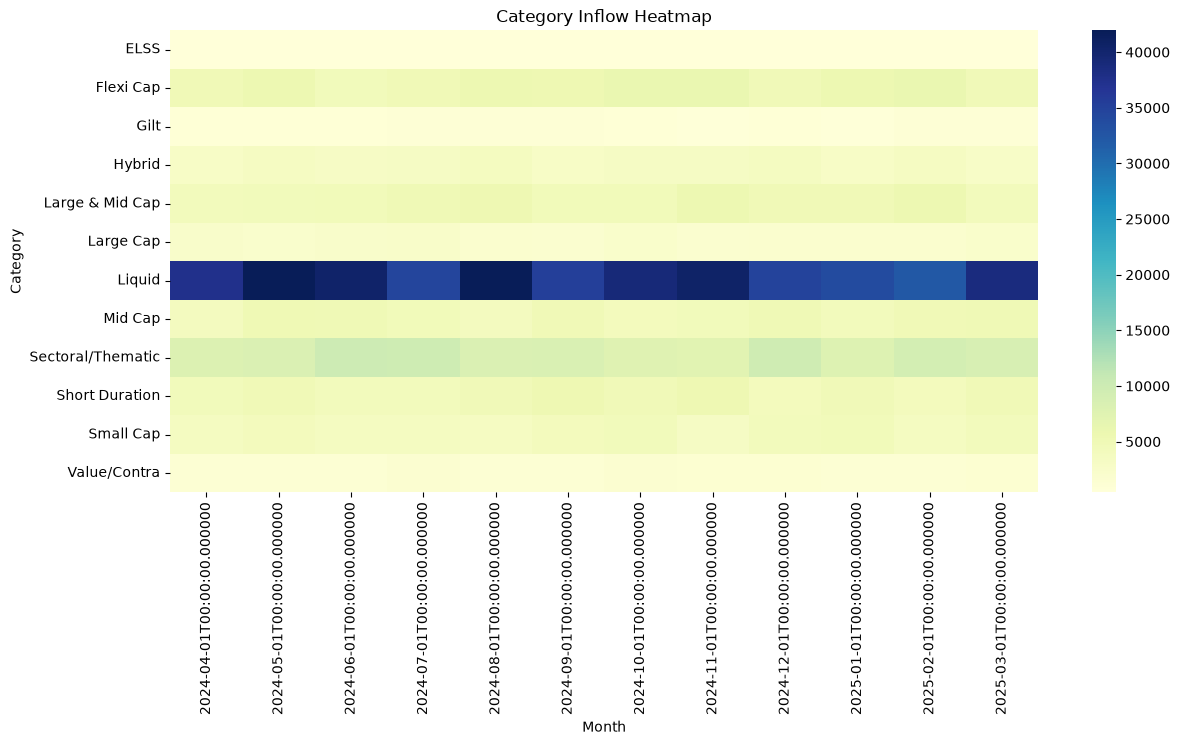

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat = pd.read_csv("data/raw/05_category_inflows.csv")

# convert month properly
cat['month'] = pd.to_datetime(cat['month'])

# pivot table for heatmap
heat_data = cat.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(14,6))
sns.heatmap(heat_data, cmap="YlGnBu")

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

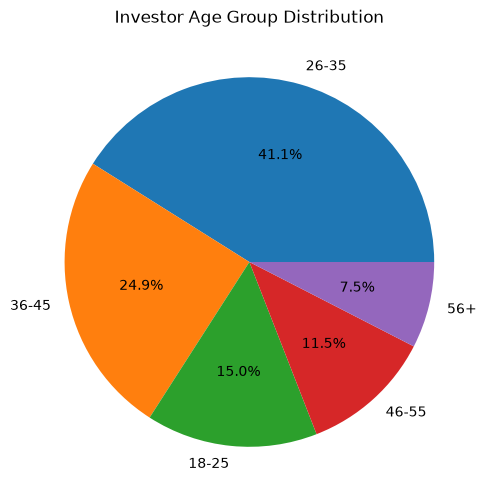

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

txn = pd.read_csv("data/raw/08_investor_transactions.csv")

# Age group distribution (Pie Chart)
age_counts = txn['age_group'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')
plt.title("Investor Age Group Distribution")
plt.show()

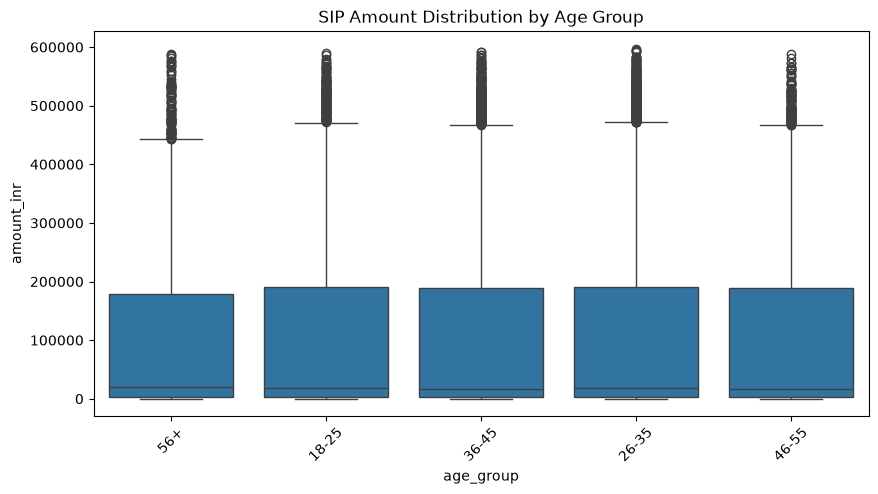

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=txn, x='age_group', y='amount_inr')

plt.title("SIP Amount Distribution by Age Group")
plt.xticks(rotation=45)
plt.show()

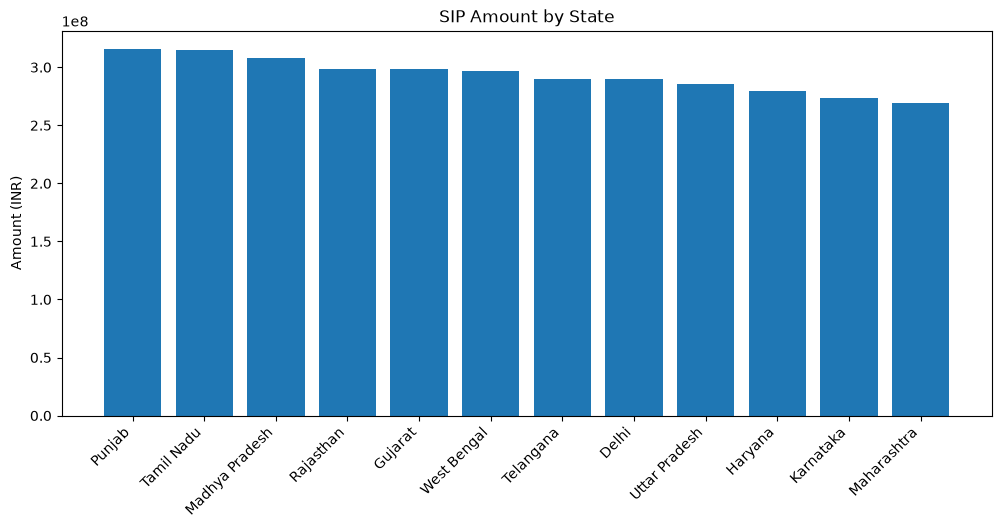

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

txn = pd.read_csv("data/raw/08_investor_transactions.csv")

state_sip = txn.groupby('state')['amount_inr'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
plt.bar(state_sip.index, state_sip.values)

plt.xticks(rotation=45, ha='right')
plt.title("SIP Amount by State")
plt.ylabel("Amount (INR)")
plt.show()

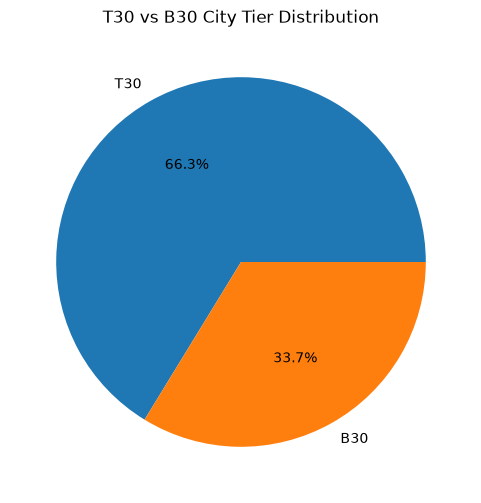

In [22]:
tier_counts = txn['city_tier'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%')
plt.title("T30 vs B30 City Tier Distribution")
plt.show()

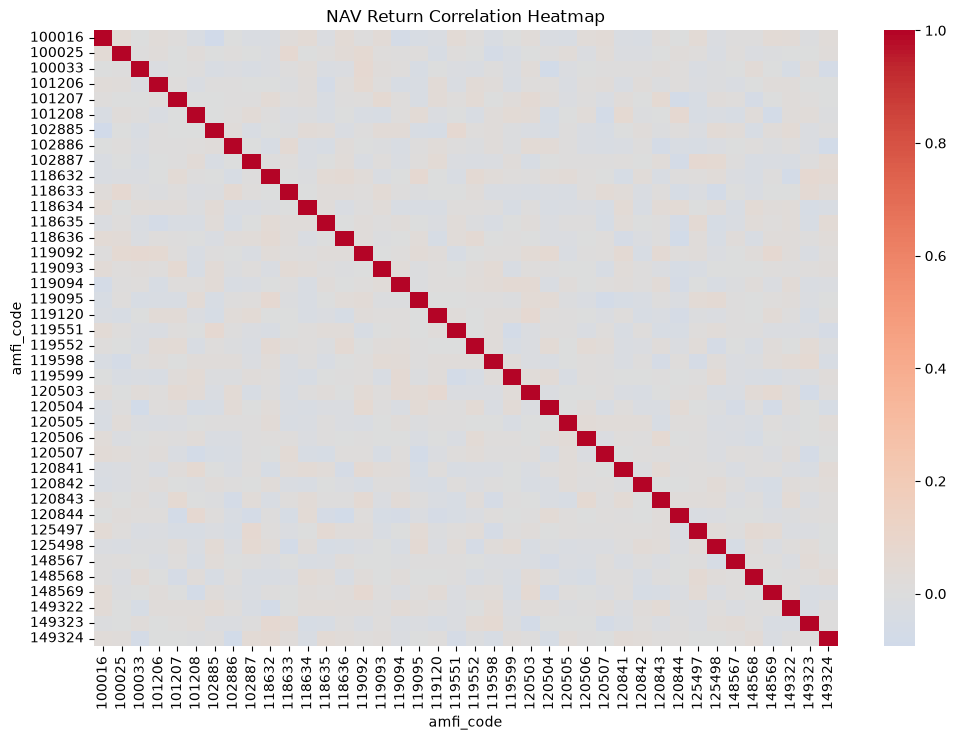

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nav_df = pd.read_csv("data/raw/02_nav_history.csv")

# Convert date
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Pivot: each fund = column, date = index
nav_pivot = nav_df.pivot(index='date', columns='amfi_code', values='nav')

# Calculate daily returns
returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr = returns.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("NAV Return Correlation Heatmap")
plt.show()